# Initial Setup #

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:/Users/kevin/Projects/fiji-event-engagement-analytics/data/raw/fiji_fall_event_preferences.csv")


In [3]:
df.shape     # how many rows, how many columns

(43, 17)

In [4]:
df.columns      # exact column names from the Google Form

Index(['Timestamp', 'Class Year',
       'How many chapter events would you say you attended last semester? (This includes everything from B.O.B. pregames to events like Senior Sendoff)',
       'Rank how likely you are to attend each type of event:    \n\nPregames (1 = NEVER, 5 = ALWAYS)',
       'Postgames  (1 = NEVER, 5 = ALWAYS)',
       'Socials/Mixers  (1 = NEVER, 5 = ALWAYS)',
       'Brotherhood Events (fam olympics, paintball, boat trip, etc.)\n(1 = NEVER, 5 = ALWAYS)',
       'Philanthropy/Fundraising Events  \n(1 = NEVER, 5 = ALWAYS)',
       'Professional/Networking Events\n(1 = NEVER, 5 = ALWAYS)',
       'Community Service Events\n(1 = NEVER, 5 = ALWAYS)',
       'Alumni Events (pig dinner, etc.)\n(1 = NEVER, 5 = ALWAYS)',
       'What day(s) for events work best for you? (Check all that apply)',
       'What's the #1 reason you'd skip an event?',
       'How do you usually hear about events?',
       'Given the circumstances, rate your satisfaction with the  Spring semes

In [5]:
df.head()

,Timestamp,Class Year,How many chapter events would you say you attended last semester? (This includes everything from B.O.B. pregames to events like Senior Sendoff),"Rank how likely you are to attend each type of event: \n\nPregames (1 = NEVER, 5 = ALWAYS)","Postgames (1 = NEVER, 5 = ALWAYS)","Socials/Mixers (1 = NEVER, 5 = ALWAYS)","Brotherhood Events (fam olympics, paintball, boat trip, etc.)\n(1 = NEVER, 5 = ALWAYS)","Philanthropy/Fundraising Events \n(1 = NEVER, 5 = ALWAYS)","Professional/Networking Events\n(1 = NEVER, 5 = ALWAYS)","Community Service Events\n(1 = NEVER, 5 = ALWAYS)","Alumni Events (pig dinner, etc.)\n(1 = NEVER, 5 = ALWAYS)",What day(s) for events work best for you? (Check all that apply),What's the #1 reason you'd skip an event?,How do you usually hear about events?,"Given the circumstances, rate your satisfaction with the Spring semester's event lineup. (1 = Unsatisfied, 5 = Very Satisfied)",Optional: One event you wish we did that we haven't?,"Optional: If we did more community service, what type of service would actually interest you?"
0,7/20/2026 12:24:56,Rising Senior,10+,5,3,5,5,5,4,4,3,"Weekday evening, Friday, Saturday, Sunday",Too tired/burnt out,GroupMe (brotherchat/important announcements),4,Island Week,More animal shelter help
1,7/20/2026 12:33:20,Rising Senior,10+,4,4,4,5,4,3,3,5,"Weekday evening, Friday, Saturday, Sunday",Conflicts with class/work,GroupMe (brotherchat/important announcements),3,Dye tournament,NaN
2,7/20/2026 12:33:46,Rising Junior,10+,4,5,4,3,2,4,5,3,"Weekday evening, Friday, Saturday, Sunday",Too tired/burnt out,GroupMe (brotherchat/important announcements),4,NaN,NaN
3,7/20/2026 12:33:51,Rising Senior,10+,3,5,4,4,4,2,3,5,"Friday, Saturday, Sunday",Conflicts with class/work,In-person/word from other brothers,3,NaN,NaN
4,7/20/2026 12:33:53,Rising Junior,10+,4,4,4,3,3,4,2,3,"Weekday evening, Friday, Saturday",Not interested in event type,GroupMe (brotherchat/important announcements),3,NaN,NaN


# Data Cleaning / Prep #

In [6]:
# renaming columns for easier access
column_map = {
    'Timestamp': 'timestamp',
    'Class Year': 'class_year',
    'How many chapter events would you say you attended last semester? (This includes everything from B.O.B. pregames to events like Senior Sendoff)': 'events_attended',
    'Rank how likely you are to attend each type of event:    \n\nPregames (1 = NEVER, 5 = ALWAYS)': 'rating_pregames',
    'Postgames  (1 = NEVER, 5 = ALWAYS)': 'rating_postgames',
    'Socials/Mixers  (1 = NEVER, 5 = ALWAYS)': 'rating_socials',
    'Brotherhood Events (fam olympics, paintball, boat trip, etc.)\n(1 = NEVER, 5 = ALWAYS)': 'rating_brotherhood',
    'Philanthropy/Fundraising Events  \n(1 = NEVER, 5 = ALWAYS)': 'rating_philanthropy',
    'Professional/Networking Events\n(1 = NEVER, 5 = ALWAYS)': 'rating_professional',
    'Community Service Events\n(1 = NEVER, 5 = ALWAYS)': 'rating_community_service',
    'Alumni Events (pig dinner, etc.)\n(1 = NEVER, 5 = ALWAYS)': 'rating_alumni',
    'What day(s) for events work best for you? (Check all that apply)': 'preferred_days',
    "What's the #1 reason you'd skip an event?": 'reason_skip_event',
    'How do you usually hear about events?': 'event_communication',
    "Given the circumstances, rate your satisfaction with the  Spring semester's event lineup. (1 = Unsatisfied, 5 = Very Satisfied)": 'satisfaction_event_lineup',
    "Optional: One event you wish we did that we haven't?": 'wished_event',
    'Optional: If we did more community service, what type of service would actually interest you?': 'community_service_interest'
}

In [7]:
df = df.rename(columns=column_map)

In [8]:
df.columns

Index(['timestamp', 'class_year', 'events_attended', 'rating_pregames',
       'rating_postgames', 'rating_socials', 'rating_brotherhood',
       'rating_philanthropy', 'rating_professional',
       'rating_community_service', 'rating_alumni', 'preferred_days',
       'reason_skip_event', 'event_communication', 'satisfaction_event_lineup',
       'wished_event', 'community_service_interest'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   timestamp                   43 non-null     str  
 1   class_year                  43 non-null     str  
 2   events_attended             43 non-null     str  
 3   rating_pregames             43 non-null     int64
 4   rating_postgames            43 non-null     int64
 5   rating_socials              43 non-null     int64
 6   rating_brotherhood          43 non-null     int64
 7   rating_philanthropy         43 non-null     int64
 8   rating_professional         43 non-null     int64
 9   rating_community_service    43 non-null     int64
 10  rating_alumni               43 non-null     int64
 11  preferred_days              43 non-null     str  
 12  reason_skip_event           43 non-null     str  
 13  event_communication         43 non-null     str  
 14  satisfaction_event_line

In [10]:
# Display value counts for categorical columns to understand the distribution of responses
for col in ['class_year', 'events_attended', 'preferred_days', 'reason_skip_event', 'event_communication']:
    print(col)
    print(df[col].value_counts())
    print()

class_year
class_year
Rising Sophomore    17
Rising Junior       15
Rising Senior       11
Name: count, dtype: int64

events_attended
events_attended
10+    29
7-9     6
4-6     4
0-3     4
Name: count, dtype: int64

preferred_days
preferred_days
Weekday evening, Friday, Saturday                               12
Weekday evening, Friday, Saturday, Sunday                        9
Friday, Saturday, Sunday                                         9
Weekday afternoon, Weekday evening, Friday, Saturday, Sunday     4
Weekday afternoon, Weekday evening, Friday, Saturday             3
Friday, Saturday                                                 3
Saturday, Sunday                                                 1
Weekday afternoon, Sunday                                        1
Weekday afternoon, Weekday evening, Saturday                     1
Name: count, dtype: int64

reason_skip_event
reason_skip_event
Conflicts with class/work       21
Not interested in event type    12
Too tired/burnt o

In [11]:
# "Lazy af" was a free-text "Other" response. Folding it into "Too tired/burnt out" since it's semantically equivalent
# Judgement call: could have also kept as standalone "Other" category
df['reason_skip_event'] = df['reason_skip_event'].replace({'Lazy af': 'Too tired/burnt out'})

df['reason_skip_event'].value_counts()     # confirming merge was successful

reason_skip_event
Conflicts with class/work       21
Not interested in event type    12
Too tired/burnt out              9
Cost                             1
Name: count, dtype: int64

In [12]:
# preferred_days into 5 separate binary columns
day_dummies = df['preferred_days'].str.get_dummies(', ')
day_dummies.columns

Index(['Friday', 'Saturday', 'Sunday', 'Weekday afternoon', 'Weekday evening'], dtype='str')

In [13]:
# renaming dummy dolumns
day_dummies = day_dummies.rename(columns={
    'Weekday afternoon': 'pref_weekday_afternoon',
    'Weekday evening': 'pref_weekday_evening',
    'Friday': 'pref_friday',
    'Saturday': 'pref_saturday',
    'Sunday': 'pref_sunday'
})

df = pd.concat([df, day_dummies], axis=1)     # axis=1 is okay because row order and index remain the same
df.columns     # confirm 5 new pref_ columns are now attached

Index(['timestamp', 'class_year', 'events_attended', 'rating_pregames',
       'rating_postgames', 'rating_socials', 'rating_brotherhood',
       'rating_philanthropy', 'rating_professional',
       'rating_community_service', 'rating_alumni', 'preferred_days',
       'reason_skip_event', 'event_communication', 'satisfaction_event_lineup',
       'wished_event', 'community_service_interest', 'pref_friday',
       'pref_saturday', 'pref_sunday', 'pref_weekday_afternoon',
       'pref_weekday_evening'],
      dtype='str')

In [14]:
df.columns[df.columns.duplicated()]  # quick check; returns empty Index([]) if clean

Index([], dtype='str')

In [15]:
df[['preferred_days', 'pref_friday', 'pref_saturday', 'pref_sunday']].head()

,preferred_days,pref_friday,pref_saturday,pref_sunday
0,"Weekday evening, Friday, Saturday, Sunday",1,1,1
1,"Weekday evening, Friday, Saturday, Sunday",1,1,1
2,"Weekday evening, Friday, Saturday, Sunday",1,1,1
3,"Friday, Saturday, Sunday",1,1,1
4,"Weekday evening, Friday, Saturday",1,1,0


In [16]:
df.columns # make sure 22 columns now present and no duplicate columns

Index(['timestamp', 'class_year', 'events_attended', 'rating_pregames',
       'rating_postgames', 'rating_socials', 'rating_brotherhood',
       'rating_philanthropy', 'rating_professional',
       'rating_community_service', 'rating_alumni', 'preferred_days',
       'reason_skip_event', 'event_communication', 'satisfaction_event_lineup',
       'wished_event', 'community_service_interest', 'pref_friday',
       'pref_saturday', 'pref_sunday', 'pref_weekday_afternoon',
       'pref_weekday_evening'],
      dtype='str')

In [17]:
# One-hot encoding class_year
class_dummies = pd.get_dummies(df['class_year'], prefix='class')   # haven't picked a model yet, so no drop_first for now
class_dummies.head()

,class_Rising Junior,class_Rising Senior,class_Rising Sophomore
0,False,True,False
1,False,True,False
2,True,False,False
3,False,True,False
4,True,False,False


In [18]:
# merge into df
df = pd.concat([df, class_dummies], axis=1)

print(df.columns[df.columns.duplicated()])    # quick check; returns empty Index([]) if clean

Index([], dtype='str')


In [19]:
df.columns    # 3 new class_ columns merged properly

Index(['timestamp', 'class_year', 'events_attended', 'rating_pregames',
       'rating_postgames', 'rating_socials', 'rating_brotherhood',
       'rating_philanthropy', 'rating_professional',
       'rating_community_service', 'rating_alumni', 'preferred_days',
       'reason_skip_event', 'event_communication', 'satisfaction_event_lineup',
       'wished_event', 'community_service_interest', 'pref_friday',
       'pref_saturday', 'pref_sunday', 'pref_weekday_afternoon',
       'pref_weekday_evening', 'class_Rising Junior', 'class_Rising Senior',
       'class_Rising Sophomore'],
      dtype='str')

In [20]:
# events_attendeed ordinal encoding
bucket_order = ['0-3', '4-6', '7-9', '10+']

df['events_attended'] = pd.Categorical(
    df['events_attended'],
    categories=bucket_order,
    ordered=True
)

df['events_attended'].dtype

CategoricalDtype(categories=['0-3', '4-6', '7-9', '10+'], ordered=True, categories_dtype=str)

In [21]:
# make events_attended numeric for modeling
df['events_attended_ordinal'] = df['events_attended'].cat.codes    # convert each category to its rank position as an int
df[['events_attended', 'events_attended_ordinal']].head(15)

,events_attended,events_attended_ordinal
0,10+,3
1,10+,3
2,10+,3
3,10+,3
4,10+,3
5,10+,3
6,10+,3
7,10+,3
8,10+,3
9,7-9,2


In [22]:
# reshaping using pd.melt to get 8 separate rows for each individual rating all 8 event types
rating_cols = ['rating_pregames', 'rating_postgames', 'rating_socials',
               'rating_brotherhood', 'rating_philanthropy', 'rating_professional',
               'rating_community_service', 'rating_alumni']

df_long = df.melt(
    id_vars = [col for col in df.columns if col not in rating_cols],
    value_vars = rating_cols,
    var_name = 'event_type',   # name of new column holding the type of event
    value_name = 'rating'      # name of the new column holding the rating value
)

df_long.shape

(344, 20)

In [23]:
df_long[['class_year', 'event_type', 'rating']].head(10)

,class_year,event_type,rating
0,Rising Senior,rating_pregames,5
1,Rising Senior,rating_pregames,4
2,Rising Junior,rating_pregames,4
3,Rising Senior,rating_pregames,3
4,Rising Junior,rating_pregames,4
5,Rising Sophomore,rating_pregames,4
6,Rising Sophomore,rating_pregames,4
7,Rising Sophomore,rating_pregames,5
8,Rising Sophomore,rating_pregames,4
9,Rising Sophomore,rating_pregames,5


In [24]:
# see first response's ratings for all 8 event types
df_long[df_long['timestamp'] == df['timestamp'].iloc[0]][['event_type', 'rating']]

,event_type,rating
0,rating_pregames,5
43,rating_postgames,3
86,rating_socials,5
129,rating_brotherhood,5
172,rating_philanthropy,5
215,rating_professional,4
258,rating_community_service,4
301,rating_alumni,3


In [25]:
# changing rating_ names back to reduce redundancy
df_long['event_type'] = df_long['event_type'].str.replace('rating_', '', regex=False)
df_long['event_type'].value_counts()

event_type
pregames             43
postgames            43
socials              43
brotherhood          43
philanthropy         43
professional         43
community_service    43
alumni               43
Name: count, dtype: int64

# EDA (also to help drive synthetic data creation decisions) #

In [26]:
# Group by class year AND event type, look at both the average rating 
# and how many people are in each group (determine if the average is trustworthy)
year_event_summary = df_long.groupby(['class_year', 'event_type'])['rating'].agg(['mean', 'count'])

year_event_summary

mean  count
class_year       event_type                        
Rising Junior    alumni             3.466667     15
                 brotherhood        4.266667     15
                 community_service  3.133333     15
                 philanthropy       3.200000     15
                 postgames          4.000000     15
                 pregames           4.200000     15
                 professional       3.333333     15
                 socials            4.533333     15
Rising Senior    alumni             3.454545     11
                 brotherhood        3.636364     11
                 community_service  2.545455     11
                 philanthropy       2.909091     11
                 postgames          3.818182     11
                 pregames           3.363636     11
                 professional       3.272727     11
                 socials            4.090909     11
Rising Sophomore alumni             3.764706     17
                 brotherhood        4.294118     17
                 community_service  3.176471     17
                 philanthropy       3.470588     17
                 postgames          3.647059     17
                 pregames           3.941176     17
                 professional       4.117647     17
                 socials            4.764706     17

Quick Takeaways: 
- Rising seniors consistently rate most event categories lower than Juniors and Sophomores ("senioritis" perhaps)
- Sophomores tend to be the highest-rating group overall

In [27]:
# For each (class_year, event_type) group, get the proportion of people
# who gave each rating value (1-5)
rating_distributions = (
    df_long
    .groupby(['class_year', 'event_type'])['rating']
    .value_counts(normalize=True)
    .sort_index()
)

rating_distributions

class_year        event_type    rating
Rising Junior     alumni        1         0.066667
                                3         0.533333
                                4         0.200000
                                5         0.200000
                  brotherhood   2         0.066667
                                            ...   
Rising Sophomore  professional  4         0.176471
                                5         0.470588
                  socials       3         0.058824
                                4         0.117647
                                5         0.823529
Name: proportion, Length: 97, dtype: float64

In [28]:
# Temporarily show all rows instead of truncating
with pd.option_context('display.max_rows', None):
    print(rating_distributions)

class_year        event_type         rating
Rising Junior     alumni             1         0.066667
                                     3         0.533333
                                     4         0.200000
                                     5         0.200000
                  brotherhood        2         0.066667
                                     3         0.133333
                                     4         0.266667
                                     5         0.533333
                  community_service  1         0.066667
                                     2         0.333333
                                     3         0.266667
                                     4         0.066667
                                     5         0.266667
                  philanthropy       1         0.066667
                                     2         0.133333
                                     3         0.466667
                                     4         0.200000
    

Some ratings were not selected at all. This doesn't necessarily mean 100% of the time, that group will never give that rating. But based on the small subset of responses, it is less likely. (Important to note this for building synthetic data generator)

In [29]:
# Isolate just one group's raw ratings, as actual 1-5 vote counts (not yet normalized)
senior_cs = df_long[
    (df_long['class_year'] == 'Rising Senior') & 
    (df_long['event_type'] == 'community_service')
]['rating']

# Raw counts per rating value, as they exist right now (rating 5 will be missing)
raw_counts = senior_cs.value_counts()
print("Before reindexing:")
print(raw_counts)

# Force it to include every rating 1-5, filling missing ones with 0
raw_counts_full = raw_counts.reindex([1, 2, 3, 4, 5], fill_value=0)
print("\nAfter reindexing:")
print(raw_counts_full)

Before reindexing:
rating
3    5
1    3
4    2
2    1
Name: count, dtype: int64

After reindexing:
rating
1    3
2    1
3    5
4    2
5    0
Name: count, dtype: int64


In [30]:
# Generalize previous code to all 24 groups
def smooth_probabilities(ratings, possible_values=[1, 2, 3, 4, 5], alpha = 0.3):   # decided this alpha based on personal experience
    """
    Takes a Series of raw rating values from one group,
    returns a Series of Laplace-smoothed probabilities for each possible rating.
    """
    counts = ratings.value_counts().reindex(possible_values, fill_value=0)
    smoothed = (counts + alpha) / (counts.sum() + alpha * len(possible_values))
    return smoothed

# Apply this function to every (class_year, event_type) group
smoothed_distributions = (
    df_long
    .groupby(['class_year', 'event_type'])['rating']
    .apply(smooth_probabilities)
)

In [31]:
# Quick check: how many rows total? Should be 24 groups × 5 ratings = 120
print(len(smoothed_distributions))

120


In [32]:
with pd.option_context('display.max_rows', None):
    print(smoothed_distributions)

class_year        event_type         (Rising Junior, alumni)
Rising Junior     alumni             1                          0.078788
                                     2                          0.018182
                                     3                          0.503030
                                     4                          0.200000
                                     5                          0.200000
                  brotherhood        1                          0.018182
                                     2                          0.078788
                                     3                          0.139394
                                     4                          0.260606
                                     5                          0.503030
                  community_service  1                          0.078788
                                     2                          0.321212
                                     3                         

In [33]:
# Raw counts of yes/no for all 5 day columns
day_columns = ['pref_friday', 'pref_saturday', 'pref_sunday', 'pref_weekday_afternoon', 'pref_weekday_evening']

for col in day_columns:
    print(col)
    print(df_long[col].value_counts())
    print()

pref_friday
pref_friday
1    320
0     24
Name: count, dtype: int64

pref_saturday
pref_saturday
1    336
0      8
Name: count, dtype: int64

pref_sunday
pref_sunday
1    192
0    152
Name: count, dtype: int64

pref_weekday_afternoon
pref_weekday_afternoon
0    272
1     72
Name: count, dtype: int64

pref_weekday_evening
pref_weekday_evening
1    232
0    112
Name: count, dtype: int64



Dividing each by 8 to determine actual people yields these results:
- Friday --> 40 yes, 3 no
- Saturday --> 42 yes, 1 no
- Sunday --> 24 yes, 19 no
- Weekday afternoon --> 9 yes, 34 no
- Weekday evening --> 29 yes, 14 no

Friday and Saturday can't be used as a comparison lever (Just a fact to try and to events Friday/Saturday)

In [34]:
# Mean/count on two strongest candidates (sunday and weekday evening)
sunday_summary = df_long.groupby(['pref_sunday', 'event_type'])['rating'].agg(['mean', 'count'])
evening_summary = df_long.groupby(['pref_weekday_evening', 'event_type'])['rating'].agg(['mean', 'count'])

print(sunday_summary)
print()
print(evening_summary)

                                   mean  count
pref_sunday event_type                        
0           alumni             3.842105     19
            brotherhood        4.000000     19
            community_service  3.000000     19
            philanthropy       3.263158     19
            postgames          4.052632     19
            pregames           3.894737     19
            professional       3.631579     19
            socials            4.736842     19
1           alumni             3.375000     24
            brotherhood        4.208333     24
            community_service  3.000000     24
            philanthropy       3.208333     24
            postgames          3.625000     24
            pregames           3.875000     24
            professional       3.625000     24
            socials            4.333333     24

                                            mean  count
pref_weekday_evening event_type                        
0                    alumni             3

Day-of-week preference does not show a consistent relationship with event-type ratings, unlike class year

In [35]:
# Checking skip event and event type relationship
# What are the categories and how many people are in each
print(df_long['reason_skip_event'].value_counts())

reason_skip_event
Conflicts with class/work       168
Not interested in event type     96
Too tired/burnt out              72
Cost                              8
Name: count, dtype: int64


Dividing each by 8 to determine actual people yields these results:
- Conflicts with class/work --> 21 
- Not interested in event type --> 12
- Too tired/burnt out --> 9
- Cost --> 1

In [36]:
skip_reason_summary = df_long.groupby(['reason_skip_event', 'event_type'])['rating'].agg(['mean', 'count'])
skip_reason_summary

mean  count
reason_skip_event            event_type                        
Conflicts with class/work    alumni             4.047619     21
                             brotherhood        4.428571     21
                             community_service  3.333333     21
                             philanthropy       3.904762     21
                             postgames          4.142857     21
                             pregames           3.857143     21
                             professional       3.714286     21
                             socials            4.571429     21
Cost                         alumni             2.000000      1
                             brotherhood        4.000000      1
                             community_service  3.000000      1
                             philanthropy       3.000000      1
                             postgames          4.000000      1
                             pregames           4.000000      1
                             professional       3.000000      1
                             socials            5.000000      1
Not interested in event type alumni             3.416667     12
                             brotherhood        3.833333     12
                             community_service  2.333333     12
                             philanthropy       2.500000     12
                             postgames          3.083333     12
                             pregames           3.916667     12
                             professional       3.500000     12
                             socials            4.416667     12
Too tired/burnt out          alumni             2.888889      9
                             brotherhood        3.777778      9
                             community_service  3.111111      9
                             philanthropy       2.666667      9
                             postgames          4.000000      9
                             pregames           3.888889      9
                             professional       3.666667      9
                             socials            4.444444      9

- Those not interested in event type vs. conflicts with class/work have lower ratings in 7 of the 8 event types
- Those too tired/burnt out vs. conflicts with class/work have lower ratings in 5 of the 8 event types

In [37]:
# Checking the distribution of attendance across different ordinal buckets
# how many people fall into each attendance bucket
print(df_long['events_attended_ordinal'].value_counts())

events_attended_ordinal
3    232
2     48
1     32
0     32
Name: count, dtype: int64


Dividing each by 8 to determine actual people yields these results:
- 0-3 --> 4
- 4-6 --> 4
- 7-9 --> 6
- 10+ --> 29

In [38]:
attendance_summary = df_long.groupby(['events_attended_ordinal', 'event_type'])['rating'].agg(['mean', 'count'])
attendance_summary

mean  count
events_attended_ordinal event_type                        
0                       alumni             3.250000      4
                        brotherhood        2.500000      4
                        community_service  1.500000      4
                        philanthropy       2.000000      4
                        postgames          3.500000      4
                        pregames           3.500000      4
                        professional       3.000000      4
                        socials            4.500000      4
1                       alumni             4.250000      4
                        brotherhood        4.500000      4
                        community_service  3.750000      4
                        philanthropy       4.000000      4
                        postgames          3.500000      4
                        pregames           3.250000      4
                        professional       4.250000      4
                        socials            4.250000      4
2                       alumni             4.000000      6
                        brotherhood        4.166667      6
                        community_service  2.166667      6
                        philanthropy       3.166667      6
                        postgames          3.333333      6
                        pregames           4.000000      6
                        professional       3.833333      6
                        socials            4.500000      6
3                       alumni             3.448276     29
                        brotherhood        4.275862     29
                        community_service  3.275862     29
                        philanthropy       3.310345     29
                        postgames          4.000000     29
                        pregames           4.000000     29
                        professional       3.586207     29
                        socials            4.551724     29

Not enough sample and valid evidence to determine that events_attended_ordinal is a notable lever to acknowledge.

In [39]:
# reason_skip_event smoothed distribution
skip_reason_distributions = (
    df_long
    .groupby(['reason_skip_event', 'event_type'])['rating']
    .apply(smooth_probabilities)
)

skip_reason_distributions

reason_skip_event          event_type  (Conflicts with class/work, alumni)
Conflicts with class/work  alumni      1                                      0.013333
                                       2                                      0.057778
                                       3                                      0.368889
                                       4                                      0.057778
                                       5                                      0.502222
                                                                                ...   
Too tired/burnt out        socials     1                                      0.028571
                                       2                                      0.028571
                                       3                                      0.219048
                                       4                                      0.123810
                                       5               

In [40]:
# Overall (dataset-wide) smoothed distribution per event_type — used as fallback for Cost
overall_distributions = (
    df_long
    .groupby(['event_type'])['rating']
    .apply(smooth_probabilities)
)

overall_distributions

event_type         alumni
alumni             1         0.029213
                   2         0.208989
                   3         0.276404
                   4         0.141573
                   5         0.343820
brotherhood        1         0.029213
                   2         0.051685
                   3         0.141573
                   4         0.366292
                   5         0.411236
community_service  1         0.119101
                   2         0.231461
                   3         0.343820
                   4         0.141573
                   5         0.164045
philanthropy       1         0.074157
                   2         0.208989
                   3         0.298876
                   4         0.253933
                   5         0.164045
postgames          1         0.029213
                   2         0.074157
                   3         0.231461
                   4         0.411236
                   5         0.253933
pregames           1    

# Synthetic Data Generator Function #

In [41]:
def blend_distributions(class_year, skip_reason, event_type, weight_class_year=0.65):
    """
    Combines the class_year distribution and reason_skip_event distribution
    for a given event_type into one final probability distribution.
    Falls back to the overall (event_type-only) distribution if skip_reason is 'Cost'.
    """
    class_year_dist = smoothed_distributions[class_year, event_type]

    if skip_reason == 'Cost':
        skip_dist = overall_distributions[event_type]
    else:
        skip_dist = skip_reason_distributions[skip_reason, event_type]

    weight_skip = 1 - weight_class_year
    final_dist = (weight_class_year * class_year_dist) + (weight_skip * skip_dist)

    return final_dist

In [42]:
# Test on example
test_result = blend_distributions('Rising Senior', 'Not interested in event type', 'community_service')
print(test_result)
print(test_result.sum())  # sanity check — should be very close to 1.0

(Rising Junior, alumni)
1    0.283081
2    0.153156
3    0.361156
4    0.153304
5    0.049304
Name: rating, dtype: float64
1.0


### Generalizing blend_distributions ###

In [43]:
from itertools import product

class_years = df_long['class_year'].unique()
skip_reasons = df_long['reason_skip_event'].unique()
event_types = df_long['event_type'].unique()

print(class_years)
print(skip_reasons)
print(event_types)

<StringArray>
['Rising Senior', 'Rising Junior', 'Rising Sophomore']
Length: 3, dtype: str
<StringArray>
[         'Too tired/burnt out',    'Conflicts with class/work',
 'Not interested in event type',                         'Cost']
Length: 4, dtype: str
<StringArray>
[         'pregames',         'postgames',           'socials',
       'brotherhood',      'philanthropy',      'professional',
 'community_service',            'alumni']
Length: 8, dtype: str


In [44]:
# full loop
final_distributions = {}

for class_year, skip_reason, event_type in product(class_years, skip_reasons, event_types):
    key = (class_year, skip_reason, event_type)
    final_distributions[key] = blend_distributions(class_year, skip_reason, event_type)

print(len(final_distributions))

96


In [45]:
check = final_distributions[('Rising Senior', 'Not interested in event type', 'community_service')]
print(check)
print(check.sum())

(Rising Junior, alumni)
1    0.283081
2    0.153156
3    0.361156
4    0.153304
5    0.049304
Name: rating, dtype: float64
1.0


Got same results here as from the first example.

### Turning Probability Distribution into One Sampled Rating ###

In [46]:
import numpy as np

def sample_rating(distribution):
    """
    Given a probability distribution (indexed by rating values 1-5),
    randomly draws one rating according to those probabilities.
    """
    ratings = distribution.index.values
    probabilities = distribution.values
    return np.random.choice(ratings, p=probabilities)

# Test it using our known worked example
test_dist = final_distributions[('Rising Senior', 'Not interested in event type', 'community_service')]
sample_rating(test_dist)

np.int64(1)

In [47]:
# run 1000 times
# expect roughly [0.283, 0.153, 0.361, 0.153, 0.049] randomness
samples = [sample_rating(test_dist) for _ in range(1000)]
print(pd.Series(samples).value_counts(normalize=True).sort_index())

1    0.274
2    0.154
3    0.364
4    0.153
5    0.055
Name: proportion, dtype: float64


### Building One Clean Synthetic Generator Function ###

In [48]:
# confirming original wide-format data variable
print(df.shape)
print(df.columns.tolist())

(43, 26)
['timestamp', 'class_year', 'events_attended', 'rating_pregames', 'rating_postgames', 'rating_socials', 'rating_brotherhood', 'rating_philanthropy', 'rating_professional', 'rating_community_service', 'rating_alumni', 'preferred_days', 'reason_skip_event', 'event_communication', 'satisfaction_event_lineup', 'wished_event', 'community_service_interest', 'pref_friday', 'pref_saturday', 'pref_sunday', 'pref_weekday_afternoon', 'pref_weekday_evening', 'class_Rising Junior', 'class_Rising Senior', 'class_Rising Sophomore', 'events_attended_ordinal']


In [49]:
# Pick one random real person's full profile
random_person = df.sample(n=1).iloc[0]
print(random_person)

timestamp                                                    7/20/2026 12:36:45
class_year                                                        Rising Junior
events_attended                                                             10+
rating_pregames                                                               4
rating_postgames                                                              4
rating_socials                                                                5
rating_brotherhood                                                            4
rating_philanthropy                                                           3
rating_professional                                                           3
rating_community_service                                                      3
rating_alumni                                                                 3
preferred_days                                         Friday, Saturday, Sunday
reason_skip_event                       

In [50]:
def generate_synthetic_ratings(person, event_types):
    """
    Given a real person's profile (class_year, reason_skip_event),
    generates a new synthetic rating for each event type.
    Returns a dict: {event_type: synthetic_rating}
    """
    class_year = person['class_year']
    skip_reason = person['reason_skip_event']
    
    new_ratings = {}
    for event_type in event_types:
        dist = final_distributions[(class_year, skip_reason, event_type)]
        new_ratings[event_type] = sample_rating(dist)
    
    return new_ratings

# Test it on the random person just pulled
test_ratings = generate_synthetic_ratings(random_person, event_types)
print(test_ratings)

{'pregames': np.int64(4), 'postgames': np.int64(5), 'socials': np.int64(4), 'brotherhood': np.int64(3), 'philanthropy': np.int64(3), 'professional': np.int64(3), 'community_service': np.int64(5), 'alumni': np.int64(3)}


In [51]:
def generate_synthetic_person(real_df, event_types):
    """
    Picks one random real person's profile, generates new synthetic ratings,
    and returns a long-format DataFrame (8 rows) for that synthetic person.
    """
    person = real_df.sample(n=1).iloc[0]
    new_ratings = generate_synthetic_ratings(person, event_types)
    
    rows = []
    for event_type, rating in new_ratings.items():
        row = {
            'class_year': person['class_year'],
            'reason_skip_event': person['reason_skip_event'],
            'pref_friday': person['pref_friday'],
            'pref_saturday': person['pref_saturday'],
            'pref_sunday': person['pref_sunday'],
            'pref_weekday_afternoon': person['pref_weekday_afternoon'],
            'pref_weekday_evening': person['pref_weekday_evening'],
            'events_attended_ordinal': person['events_attended_ordinal'],
            'event_type': event_type,
            'rating': rating,
            'is_synthetic': True
        }
        rows.append(row)
    
    return pd.DataFrame(rows)

# Test on one synthetic person
test_person_df = generate_synthetic_person(df, event_types)
test_person_df

,class_year,reason_skip_event,pref_friday,pref_saturday,pref_sunday,pref_weekday_afternoon,pref_weekday_evening,events_attended_ordinal,event_type,rating,is_synthetic
0,Rising Junior,Not interested in event type,1,1,0,0,1,3,pregames,3,True
1,Rising Junior,Not interested in event type,1,1,0,0,1,3,postgames,4,True
2,Rising Junior,Not interested in event type,1,1,0,0,1,3,socials,5,True
3,Rising Junior,Not interested in event type,1,1,0,0,1,3,brotherhood,4,True
4,Rising Junior,Not interested in event type,1,1,0,0,1,3,philanthropy,4,True
5,Rising Junior,Not interested in event type,1,1,0,0,1,3,professional,3,True
6,Rising Junior,Not interested in event type,1,1,0,0,1,3,community_service,4,True
7,Rising Junior,Not interested in event type,1,1,0,0,1,3,alumni,2,True


In [52]:
def generate_synthetic_dataset(real_df, event_types, n_people):
    """
    Generates a full synthetic dataset by creating n_people synthetic people,
    each with 8 rows (one per event_type), and combining them into one DataFrame.
    """
    all_people = [generate_synthetic_person(real_df, event_types) for _ in range(n_people)]
    return pd.concat(all_people, ignore_index=True)

# Generate a small test batch
synthetic_test = generate_synthetic_dataset(df, event_types, n_people=5)
print(synthetic_test.shape)
synthetic_test

(40, 11)


,class_year,reason_skip_event,pref_friday,pref_saturday,pref_sunday,pref_weekday_afternoon,pref_weekday_evening,events_attended_ordinal,event_type,rating,is_synthetic
0,Rising Senior,Conflicts with class/work,1,1,0,1,1,3,pregames,2,True
1,Rising Senior,Conflicts with class/work,1,1,0,1,1,3,postgames,4,True
2,Rising Senior,Conflicts with class/work,1,1,0,1,1,3,socials,4,True
3,Rising Senior,Conflicts with class/work,1,1,0,1,1,3,brotherhood,4,True
4,Rising Senior,Conflicts with class/work,1,1,0,1,1,3,philanthropy,1,True
5,Rising Senior,Conflicts with class/work,1,1,0,1,1,3,professional,4,True
6,Rising Senior,Conflicts with class/work,1,1,0,1,1,3,community_service,4,True
7,Rising Senior,Conflicts with class/work,1,1,0,1,1,3,alumni,5,True
8,Rising Junior,Conflicts with class/work,1,1,0,0,1,3,pregames,4,True
9,Rising Junior,Conflicts with class/work,1,1,0,0,1,3,postgames,5,True


# Generating Whole Synthetic Dataset #

In [53]:
# Generate the full synthetic dataset with 300 synthetic people
synthetic_data = generate_synthetic_dataset(df, event_types, n_people=300)
print(synthetic_data.shape)
synthetic_data.head(16)  # first 2 synthetic people, to eyeball

(2400, 11)


,class_year,reason_skip_event,pref_friday,pref_saturday,pref_sunday,pref_weekday_afternoon,pref_weekday_evening,events_attended_ordinal,event_type,rating,is_synthetic
0,Rising Sophomore,Conflicts with class/work,1,1,0,0,1,3,pregames,5,True
1,Rising Sophomore,Conflicts with class/work,1,1,0,0,1,3,postgames,3,True
2,Rising Sophomore,Conflicts with class/work,1,1,0,0,1,3,socials,5,True
3,Rising Sophomore,Conflicts with class/work,1,1,0,0,1,3,brotherhood,4,True
4,Rising Sophomore,Conflicts with class/work,1,1,0,0,1,3,philanthropy,5,True
5,Rising Sophomore,Conflicts with class/work,1,1,0,0,1,3,professional,3,True
6,Rising Sophomore,Conflicts with class/work,1,1,0,0,1,3,community_service,4,True
7,Rising Sophomore,Conflicts with class/work,1,1,0,0,1,3,alumni,2,True
8,Rising Sophomore,Conflicts with class/work,1,1,0,0,1,3,pregames,5,True
9,Rising Sophomore,Conflicts with class/work,1,1,0,0,1,3,postgames,4,True


In [54]:
# Compare mean rating by class_year, real vs synthetic
real_by_class = df_long.groupby('class_year')['rating'].mean()
synthetic_by_class = synthetic_data.groupby('class_year')['rating'].mean()

comparison = pd.DataFrame({'real': real_by_class, 'synthetic': synthetic_by_class})
print(comparison)

                      real  synthetic
class_year                           
Rising Junior     3.766667   3.700000
Rising Senior     3.386364   3.425676
Rising Sophomore  3.897059   3.776940


In [55]:
# Compare mean rating by reason_skip_event, real vs synthetic
real_by_skip = df_long.groupby('reason_skip_event')['rating'].mean()
synthetic_by_skip = synthetic_data.groupby('reason_skip_event')['rating'].mean()

comparison_skip = pd.DataFrame({'real': real_by_skip, 'synthetic': synthetic_by_skip})
print(comparison_skip)

                                  real  synthetic
reason_skip_event                                
Conflicts with class/work     4.000000   3.759058
Cost                          3.500000   3.890625
Not interested in event type  3.375000   3.538793
Too tired/burnt out           3.555556   3.595149


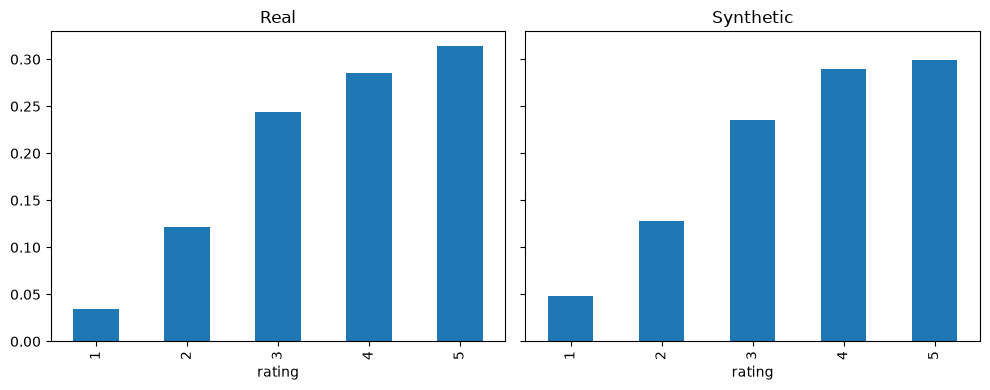

In [56]:
# visual distribution of ratings, real vs synthetic
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
df_long['rating'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=axes[0], title='Real')
synthetic_data['rating'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=axes[1], title='Synthetic')
plt.tight_layout()
plt.show()

In [57]:
synthetic_data.to_csv('../data/processed/synthetic_data.csv', index=False)

In [58]:
import os
print(os.listdir('../data/processed'))

['synthetic_data.csv']


# Predictive Modeling #

In [59]:
from sklearn.model_selection import train_test_split

# df is the wide, pre-melt data: 43 rows, one per person each row
train_people, test_people = train_test_split(
    df,
    test_size=13/43,        # ~13 people held out, matching our planned split
    stratify=df['class_year'],  # proportionally split by class year
    random_state=42          # any fixed number — just makes the split reproducible
)

print(train_people.shape, test_people.shape)
print(train_people['class_year'].value_counts(normalize=True))
print(test_people['class_year'].value_counts(normalize=True))

(30, 26) (13, 26)
class_year
Rising Sophomore    0.400000
Rising Junior       0.333333
Rising Senior       0.266667
Name: proportion, dtype: float64
class_year
Rising Junior       0.384615
Rising Sophomore    0.384615
Rising Senior       0.230769
Name: proportion, dtype: float64


In [60]:
# melting each group into long format separetely

rating_cols = [c for c in df.columns if c.startswith('rating_')]
id_cols = [c for c in df.columns if c not in rating_cols]

train_long = train_people.melt(
    id_vars=id_cols,
    value_vars=rating_cols,
    var_name='event_type',
    value_name='rating'
)

test_long = test_people.melt(
    id_vars=id_cols,
    value_vars=rating_cols,
    var_name='event_type',
    value_name='rating'
)

# check
print(train_long.shape)  # expect (30*8, ...) = (240, ...)
print(test_long.shape)   # expect (13*8, ...) = (104, ...)

(240, 20)
(104, 20)


In [62]:
print(train_long['event_type'].unique())
print(test_long['event_type'].unique())


<StringArray>
[         'rating_pregames',         'rating_postgames',
           'rating_socials',       'rating_brotherhood',
      'rating_philanthropy',      'rating_professional',
 'rating_community_service',            'rating_alumni']
Length: 8, dtype: str
<StringArray>
[         'rating_pregames',         'rating_postgames',
           'rating_socials',       'rating_brotherhood',
      'rating_philanthropy',      'rating_professional',
 'rating_community_service',            'rating_alumni']
Length: 8, dtype: str


In [65]:
# drop the 'rating_' prefix
train_long['event_type'] = train_long['event_type'].str.replace('rating_', '', regex=False)
test_long['event_type'] = test_long['event_type'].str.replace('rating_', '', regex=False)

In [66]:
print(train_long['event_type'].unique())
print(test_long['event_type'].unique())


<StringArray>
[         'pregames',         'postgames',           'socials',
       'brotherhood',      'philanthropy',      'professional',
 'community_service',            'alumni']
Length: 8, dtype: str
<StringArray>
[         'pregames',         'postgames',           'socials',
       'brotherhood',      'philanthropy',      'professional',
 'community_service',            'alumni']
Length: 8, dtype: str


In [68]:
synthetic_data = pd.read_csv('../data/processed/synthetic_data.csv')
print(synthetic_data['event_type'].unique())

<StringArray>
[         'pregames',         'postgames',           'socials',
       'brotherhood',      'philanthropy',      'professional',
 'community_service',            'alumni']
Length: 8, dtype: str


In [ ]:
# Build full training set
combined_train = pd.concat([train_long, synthetic_data], ignore_index=True)
print(combined_train.shape)  

(2640, 21)


In [70]:
combined_train.isna().sum()

timestamp                     2400
class_year                       0
events_attended               2400
preferred_days                2400
reason_skip_event                0
event_communication           2400
satisfaction_event_lineup     2400
wished_event                  2520
community_service_interest    2560
pref_friday                      0
pref_saturday                    0
pref_sunday                      0
pref_weekday_afternoon           0
pref_weekday_evening             0
class_Rising Junior           2400
class_Rising Senior           2400
class_Rising Sophomore        2400
events_attended_ordinal          0
event_type                       0
rating                           0
is_synthetic                   240
dtype: int64

In [71]:
combined_train['is_synthetic'] = combined_train['is_synthetic'].fillna(False)

In [72]:
feature_cols = ['class_year', 'reason_skip_event', 'event_type']

X_train = pd.get_dummies(combined_train[feature_cols], drop_first=True)
y_train = combined_train['rating']

print(X_train.shape)
print(X_train.columns.tolist())

(2640, 12)
['class_year_Rising Senior', 'class_year_Rising Sophomore', 'reason_skip_event_Cost', 'reason_skip_event_Not interested in event type', 'reason_skip_event_Too tired/burnt out', 'event_type_brotherhood', 'event_type_community_service', 'event_type_philanthropy', 'event_type_postgames', 'event_type_pregames', 'event_type_professional', 'event_type_socials']


In [73]:
# test set
X_test = pd.get_dummies(test_long[feature_cols], drop_first=True)
y_test = test_long['rating']

print(X_test.shape)
print(X_test.columns.tolist())

(104, 11)
['class_year_Rising Senior', 'class_year_Rising Sophomore', 'reason_skip_event_Not interested in event type', 'reason_skip_event_Too tired/burnt out', 'event_type_brotherhood', 'event_type_community_service', 'event_type_philanthropy', 'event_type_postgames', 'event_type_pregames', 'event_type_professional', 'event_type_socials']


In [74]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [75]:
print(X_test.shape)
print(X_test.columns.tolist() == X_train.columns.tolist())

(104, 12)
True


In [76]:
import mord
print(mord.__version__)

0.7


In [77]:
# Model creation
# Fit an ordinal logistic regression model using the Mord library
from mord import LogisticAT

model = LogisticAT(alpha=1.0)  # alpha determines the regularization strength
model.fit(X_train, y_train)

,alpha,1.0
,verbose,0
,max_iter,1000
Name,Type,Value
classes_,"ndarray[int64](5,)","[1,2,3,4,5]"
coef_,"ndarray[float64](12,)","[-0.5 , 0.15,-0.16,..., 0.44, 0.18, 1.71]"
n_class_,int64,np.int64(5)
theta_,"ndarray[float64](4,)","[-3.18,-1.69,-0.4 , 0.95]"


In [79]:
# check 
train_preds = model.predict(X_train)
print(train_preds[:10])
print(y_train[:10].values)

[4 4 4 4 4 4 4 3 3 4]
[4 4 4 5 4 4 4 5 3 4]


In [80]:
# metrics (main to look at is mae)
from sklearn.metrics import mean_absolute_error, accuracy_score

test_preds = model.predict(X_test)

mae = mean_absolute_error(y_test, test_preds)
acc = accuracy_score(y_test, test_preds)

print(f"MAE: {mae:.3f}")
print(f"Accuracy: {acc:.3f}")

MAE: 0.798
Accuracy: 0.337


In [81]:
# baseline comparison
baseline_pred = np.full_like(test_preds, fill_value=y_train.mode()[0])
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print(f"Baseline MAE (always predict most common rating): {baseline_mae:.3f}")

Baseline MAE (always predict most common rating): 1.471


In [82]:
# evaluate on each event type
eval_df = test_long.copy()
eval_df['predicted'] = test_preds

per_event_mae = eval_df.groupby('event_type').apply(
    lambda g: mean_absolute_error(g['rating'], g['predicted'])
)
print(per_event_mae.sort_values())

event_type
socials              0.461538
brotherhood          0.538462
pregames             0.615385
postgames            0.692308
philanthropy         0.846154
community_service    0.923077
professional         1.000000
alumni               1.307692
dtype: float64


In [83]:
# Real proportions of reason_skip_event within each class_year
reason_weights = df.groupby('class_year')['reason_skip_event'].value_counts(normalize=True)
print(reason_weights)

class_year        reason_skip_event           
Rising Junior     Conflicts with class/work       0.466667
                  Not interested in event type    0.333333
                  Too tired/burnt out             0.200000
Rising Senior     Conflicts with class/work       0.545455
                  Too tired/burnt out             0.272727
                  Not interested in event type    0.181818
Rising Sophomore  Conflicts with class/work       0.470588
                  Not interested in event type    0.294118
                  Too tired/burnt out             0.176471
                  Cost                            0.058824
Name: proportion, dtype: float64


In [85]:
# Building full prediction grid.
# Get the real, valid (class_year, reason_skip_event) combos with their weights
weights_df = reason_weights.reset_index(name='weight')
weights_df.columns = ['class_year', 'reason_skip_event', 'weight']

# Cross with all 8 event types
event_types = df_long['event_type'].unique()  # or synthetic_data['event_type'].unique()
grid = weights_df.merge(pd.DataFrame({'event_type': event_types}), how='cross')

print(grid.shape)  # expect len(weights_df) * 8
grid.head(10)

(80, 4)


,class_year,reason_skip_event,weight,event_type
0,Rising Junior,Conflicts with class/work,0.466667,pregames
1,Rising Junior,Conflicts with class/work,0.466667,postgames
2,Rising Junior,Conflicts with class/work,0.466667,socials
3,Rising Junior,Conflicts with class/work,0.466667,brotherhood
4,Rising Junior,Conflicts with class/work,0.466667,philanthropy
5,Rising Junior,Conflicts with class/work,0.466667,professional
6,Rising Junior,Conflicts with class/work,0.466667,community_service
7,Rising Junior,Conflicts with class/work,0.466667,alumni
8,Rising Junior,Not interested in event type,0.333333,pregames
9,Rising Junior,Not interested in event type,0.333333,postgames


In [86]:
X_grid = pd.get_dummies(grid[['class_year', 'reason_skip_event', 'event_type']], drop_first=True)
X_grid = X_grid.reindex(columns=X_train.columns, fill_value=0)

grid['predicted_rating'] = model.predict(X_grid)
grid.head(10)

,class_year,reason_skip_event,weight,event_type,predicted_rating
0,Rising Junior,Conflicts with class/work,0.466667,pregames,4
1,Rising Junior,Conflicts with class/work,0.466667,postgames,4
2,Rising Junior,Conflicts with class/work,0.466667,socials,5
3,Rising Junior,Conflicts with class/work,0.466667,brotherhood,4
4,Rising Junior,Conflicts with class/work,0.466667,philanthropy,4
5,Rising Junior,Conflicts with class/work,0.466667,professional,4
6,Rising Junior,Conflicts with class/work,0.466667,community_service,3
7,Rising Junior,Conflicts with class/work,0.466667,alumni,4
8,Rising Junior,Not interested in event type,0.333333,pregames,4
9,Rising Junior,Not interested in event type,0.333333,postgames,4


In [87]:
# Weighted aggregation into final table
def weighted_avg(group):
    return (group['predicted_rating'] * group['weight']).sum() / group['weight'].sum()

summary_table = grid.groupby(['class_year', 'event_type']).apply(weighted_avg).reset_index(name='weighted_avg_rating')
summary_table_pivot = summary_table.pivot(index='event_type', columns='class_year', values='weighted_avg_rating')
print(summary_table_pivot)

class_year         Rising Junior  Rising Senior  Rising Sophomore
event_type                                                       
alumni                  3.666667       3.000000          4.000000
brotherhood             4.000000       4.000000          4.470588
community_service       3.000000       3.000000          3.000000
philanthropy            3.466667       3.000000          3.529412
postgames               4.000000       3.545455          4.000000
pregames                4.000000       3.545455          4.000000
professional            4.000000       3.545455          4.000000
socials                 5.000000       4.545455          5.000000


In [88]:
# % predicted to rate 4 or 5
grid['is_high_rating'] = (grid['predicted_rating'] >= 4).astype(int)

pct_high = grid.groupby(['class_year', 'event_type']).apply(
    lambda g: (g['is_high_rating'] * g['weight']).sum() / g['weight'].sum()
).reset_index(name='pct_rating_4_plus')

pct_high_pivot = pct_high.pivot(index='event_type', columns='class_year', values='pct_rating_4_plus')
print(pct_high_pivot)

class_year         Rising Junior  Rising Senior  Rising Sophomore
event_type                                                       
alumni                  0.666667       0.000000          1.000000
brotherhood             1.000000       1.000000          1.000000
community_service       0.000000       0.000000          0.000000
philanthropy            0.466667       0.000000          0.529412
postgames               1.000000       0.545455          1.000000
pregames                1.000000       0.545455          1.000000
professional            1.000000       0.545455          1.000000
socials                 1.000000       1.000000          1.000000


In [89]:
# Real class_year counts from original wide data
class_counts = df['class_year'].value_counts(normalize=True)
print(class_counts)

# Weight each event_type's average rating by actual class_year proportions
summary_table_reset = summary_table.copy()  # class_year, event_type, weighted_avg_rating
summary_table_reset['chapter_weight'] = summary_table_reset['class_year'].map(class_counts)

emphasis = summary_table_reset.groupby('event_type').apply(
    lambda g: (g['weighted_avg_rating'] * g['chapter_weight']).sum() / g['chapter_weight'].sum()
).reset_index(name='suggested_emphasis_score')

emphasis = emphasis.sort_values('suggested_emphasis_score', ascending=False)
print(emphasis)

class_year
Rising Sophomore    0.395349
Rising Junior       0.348837
Rising Senior       0.255814
Name: proportion, dtype: float64
          event_type  suggested_emphasis_score
7            socials                  4.883721
1        brotherhood                  4.186047
4          postgames                  3.883721
5           pregames                  3.883721
6       professional                  3.883721
0             alumni                  3.627907
3       philanthropy                  3.372093
2  community_service                  3.000000


# Outputs #

In [91]:
import os
os.makedirs('../outputs', exist_ok=True)

summary_table_pivot.to_csv('../outputs/ratings_by_class_year.csv')
pct_high_pivot.to_csv('../outputs/pct_rating_4plus_by_class_year.csv')
emphasis.to_csv('../outputs/suggested_emphasis.csv', index=False)
per_event_mae.to_csv('../outputs/per_event_mae.csv')

pd.DataFrame({
    'metric': ['MAE', 'Accuracy', 'Baseline MAE (most common rating)'],
    'value': [mae, acc, baseline_mae]
}).to_csv('../outputs/model_metrics.csv', index=False)

print("Saved:", os.listdir('../outputs'))

Saved: ['model_metrics.csv', 'pct_rating_4plus_by_class_year.csv', 'per_event_mae.csv', 'ratings_by_class_year.csv', 'suggested_emphasis.csv']
